# Subfase 8b — Calibración de probabilidades (h5)

Objetivo: evaluar la calibración de modelos clásicos y cuánticos usando `predict_proba` sobre el set de prueba (30 observaciones).

Salidas:
- `results/fase4_comparativa/BVG_subfase8b_calibracion.csv`
- `results/fase4_comparativa/BVG_calibracion_plot.png`

## Nota sobre Platt scaling (SVC lineal, C=0.1)

El SVC lineal con `C=0.1` usa Platt scaling para mapear los scores de decisión a probabilidades mediante una sigmoide. Un `C` pequeño regulariza fuerte y tiende a evitar scores extremadamente grandes, pero cuando los scores son muy extremos (muy negativos o muy positivos) la sigmoide satura y las probabilidades se acercan a 0 o 1. Esta saturación explica por qué, aun con un modelo lineal, los extremos del score pueden generar probabilidades poco sensibles a variaciones locales, afectando la calibración.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute

In [2]:
from bvg_core.config import COMPANIES, GLOBAL_SEED, TEST_SIZE
from bvg_core.splits import temporal_split_company
from bvg_core.utils import safe_company

np.random.seed(GLOBAL_SEED)

ROOT = Path('..')
DATASET_PATH = ROOT / 'data' / 'processed' / 'BVG_features_svc_master.csv'
CLASSICAL_DIR = ROOT / 'models' / 'classical'
QUANTUM_DIR = ROOT / 'models' / 'quantum'
OUT_DIR = ROOT / 'results' / 'fase4_comparativa'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / 'BVG_subfase8b_calibracion.csv'
OUT_PNG = OUT_DIR / 'BVG_calibracion_plot.png'

DATE_COL = 'fecha'
COMPANY_COL = 'empresa'
TARGET_COL = 'target_up_h5'
HORIZONTE_COL = 'horizonte'

TEST_SIZE = TEST_SIZE
N_BINS = 5

COMPANIES = COMPANIES
MODEL_FAMILIES = ['classical', 'quantum']

EXCLUDE = {
    DATE_COL, COMPANY_COL, HORIZONTE_COL,
    'target_up_h1', 'target_up_h5', 'target_up_h20',
    'ret_fwd_h1', 'ret_fwd_h5', 'ret_fwd_h20',
}

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [3]:
def compute_ece_manual(y_true: np.ndarray, proba: np.ndarray, n_bins: int = N_BINS) -> dict:
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(proba, bins, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    acc = []
    conf = []
    counts = []
    total = len(proba)
    ece = 0.0

    for b in range(n_bins):
        mask = bin_ids == b
        count = int(np.sum(mask))
        counts.append(count)
        if count == 0:
            acc.append(np.nan)
            conf.append(np.nan)
            continue
        acc_b = float(np.mean(y_true[mask]))
        conf_b = float(np.mean(proba[mask]))
        acc.append(acc_b)
        conf.append(conf_b)
        ece += (count / total) * abs(acc_b - conf_b)

    return {
        'ece': float(ece),
        'bin_edges': bins,
        'bin_acc': np.array(acc),
        'bin_conf': np.array(conf),
        'bin_counts': np.array(counts),
    }

def load_classical_model(path: Path):
    if not path.exists():
        raise FileNotFoundError(f'Modelo clásico no encontrado: {path}')
    return joblib.load(path)

def load_quantum_artifacts(prefix: str) -> dict:
    scaler_path = QUANTUM_DIR / f'{prefix}_scaler.joblib'
    pca_path = QUANTUM_DIR / f'{prefix}_pca.joblib'
    svc_path = QUANTUM_DIR / f'{prefix}_svc.joblib'
    cfg_path = QUANTUM_DIR / f'{prefix}_kernel_config.json'

    for p in [scaler_path, pca_path, svc_path, cfg_path]:
        if not p.exists():
            raise FileNotFoundError(f'Artifacto cuántico no encontrado: {p}')

    scaler = joblib.load(scaler_path)
    pca = joblib.load(pca_path)
    svc = joblib.load(svc_path)
    cfg = json.loads(cfg_path.read_text(encoding='utf-8'))

    return {'scaler': scaler, 'pca': pca, 'svc': svc, 'config': cfg}

def build_quantum_kernel(cfg: dict) -> FidelityQuantumKernel:
    feature_map = zz_feature_map(
        feature_dimension=int(cfg['feature_dimension']),
        reps=int(cfg['reps']),
        entanglement=cfg['entanglement'],
    )
    fidelity = ComputeUncompute(sampler=StatevectorSampler(seed=GLOBAL_SEED))
    return FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

def predict_quantum_proba(bundle: dict, X_train: pd.DataFrame, X_test: pd.DataFrame) -> np.ndarray:
    scaler = bundle['scaler']
    pca = bundle['pca']
    svc = bundle['svc']
    qkernel = build_quantum_kernel(bundle['config'])

    X_train_q = pca.transform(scaler.transform(X_train))
    X_test_q = pca.transform(scaler.transform(X_test))

    K_test = qkernel.evaluate(x_vec=X_test_q, y_vec=X_train_q)
    proba = svc.predict_proba(K_test)[:, 1]
    return proba

In [5]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Dataset no encontrado: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH)

if HORIZONTE_COL in df.columns:
    df = df.loc[df[HORIZONTE_COL].astype(str) == 'h5'].copy()
else:
    df = df.copy()
    df.loc[:, HORIZONTE_COL] = 'h5'

required = {DATE_COL, COMPANY_COL, TARGET_COL}
missing = sorted(required.difference(df.columns))
if missing:
    raise ValueError(f'Columnas faltantes: {missing}')

feature_cols = [c for c in df.columns if c not in EXCLUDE]
if not feature_cols:
    raise ValueError('No se pudieron inferir feature_cols.')

df = df.assign(**{DATE_COL: pd.to_datetime(df[DATE_COL], errors='coerce')})
df = df.dropna(subset=feature_cols + [TARGET_COL, DATE_COL, COMPANY_COL]).copy()
if df.empty:
    raise ValueError('Dataset vacío tras limpieza de NaN.')

df = df.sort_values([COMPANY_COL, DATE_COL], kind='stable').reset_index(drop=True)
df.head()

,fecha,empresa,close_last,close_vwap,volume_shares_day,turnover_value_day,n_trades_day,ret_lag_1,ret_lag_2,ret_lag_3,mom_3,mom_5,mom_10,vol_5,vol_10,regime_vol_ratio,ma_5,ma_10,ma_gap,price_vs_ma10,rsi_14,turnover_log1p,volume_log1p,avg_trade_size_log1p,amihud_5,days_since_trade,ret_fwd_h1,ret_fwd_h5,ret_fwd_h20,target_up_h1,target_up_h5,target_up_h20,horizonte
0,2019-02-13,BANCO GUAYAQUIL S.A.,0.97,0.97,35000.0,33950.0,1.0,0.040822,-0.040822,0.000000,3.469447e-17,4.082199e-02,0.030459,0.034154,0.024103,1.416994,0.984,0.975,0.009,0.025641,62.452022,10.432674,10.463132,10.463132,0.000016,1.0,0.030459,0.030459,-0.010363,1.0,1.0,0.0,h5
1,2019-02-19,BANCO GUAYAQUIL S.A.,1.00,1.00,2046.0,2046.0,6.0,-0.030459,0.040822,-0.040822,-3.045921e-02,1.036279e-02,0.010363,0.038424,0.026100,1.472155,0.986,0.976,0.010,-0.006148,52.665650,7.624131,7.624131,5.834811,0.000016,6.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0,h5
2,2019-02-20,BANCO GUAYAQUIL S.A.,1.00,1.00,1500.0,1500.0,1.0,0.030459,-0.030459,0.040822,4.082199e-02,1.144917e-16,0.030459,0.036015,0.027627,1.303608,0.986,0.979,0.007,0.021450,59.078190,7.313887,7.313887,7.313887,0.000019,1.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0,h5
3,2019-02-21,BANCO GUAYAQUIL S.A.,1.00,1.00,591494.0,591494.0,14.0,0.000000,0.030459,-0.030459,7.979728e-17,1.144917e-16,0.030459,0.036015,0.027627,1.303608,0.986,0.982,0.004,0.018330,59.078190,13.290409,13.290409,10.651373,0.000019,1.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0,h5
4,2019-02-26,BANCO GUAYAQUIL S.A.,1.00,1.00,2771.0,2771.0,1.0,0.000000,0.000000,0.030459,3.045921e-02,4.082199e-02,0.030459,0.028234,0.027627,1.021964,0.994,0.985,0.009,0.015228,57.100950,7.927324,7.927324,7.927324,0.000003,5.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0,h5


In [6]:
results = {}
metrics_rows = []

for company in COMPANIES:
    _, _, X_train, y_train, X_test, y_test = temporal_split_company(
        df,
        company,
        test_size=TEST_SIZE,
        company_col=COMPANY_COL,
        date_col=DATE_COL,
        target_col=TARGET_COL,
        feature_cols=feature_cols,
    )
    y_test_np = y_test.to_numpy(dtype=int)
   
    for model_family in MODEL_FAMILIES:
        prefix = f"{safe_company(company)}_h5"
        if model_family == 'classical':
            model_path = CLASSICAL_DIR / f'{prefix}_pipeline.joblib'
            pipeline = load_classical_model(model_path)
            proba = pipeline.predict_proba(X_test)[:, 1]
        else:
            bundle = load_quantum_artifacts(prefix)
            proba = predict_quantum_proba(bundle, X_train, X_test)

        prob_true, prob_pred = calibration_curve(y_test_np, proba, n_bins=N_BINS)
        ece_payload = compute_ece_manual(y_test_np, proba, n_bins=N_BINS)

        mean_proba = float(np.mean(proba))
        std_proba = float(np.std(proba))
        pct_above_60 = float(np.mean(proba > 0.60) * 100.0)
        pct_below_40 = float(np.mean(proba < 0.40) * 100.0)

        key = (company, model_family)
        results[key] = {
            'y_test': y_test_np,
            'proba': proba,
            'prob_true': prob_true,
            'prob_pred': prob_pred,
            'ece': ece_payload['ece'],
            'bin_counts': ece_payload['bin_counts'],
        }

        metrics_rows.append({
            'company': company,
            'model_family': model_family,
            'ece': ece_payload['ece'],
            'mean_proba': mean_proba,
            'std_proba': std_proba,
            'pct_proba_above_60': pct_above_60,
            'pct_proba_below_40': pct_below_40,
        })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[[
    'company', 'model_family', 'ece', 'mean_proba', 'std_proba',
    'pct_proba_above_60', 'pct_proba_below_40'
]]

metrics_df.to_csv(OUT_CSV, index=False)
metrics_df

C:\Users\leynd\AppData\Local\Temp\ipykernel_20392\3881141055.py:60: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(
C:\Users\leynd\AppData\Local\Temp\ipykernel_20392\3881141055.py:60: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


,company,model_family,ece,mean_proba,std_proba,pct_proba_above_60,pct_proba_below_40
0,BANCO GUAYAQUIL S.A.,classical,0.039081,0.858456,0.026948,100.0,0.000000
1,BANCO GUAYAQUIL S.A.,quantum,0.399190,0.434143,0.032684,0.0,13.333333
2,CORPORACION FAVORITA C.A.,classical,0.239161,0.394172,0.057934,0.0,50.000000
3,CORPORACION FAVORITA C.A.,quantum,0.265538,0.367795,0.015530,0.0,96.666667


C:\Users\leynd\AppData\Local\Temp\ipykernel_20392\1308862238.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


WindowsPath('../results/fase4_comparativa/BVG_calibracion_plot.png')

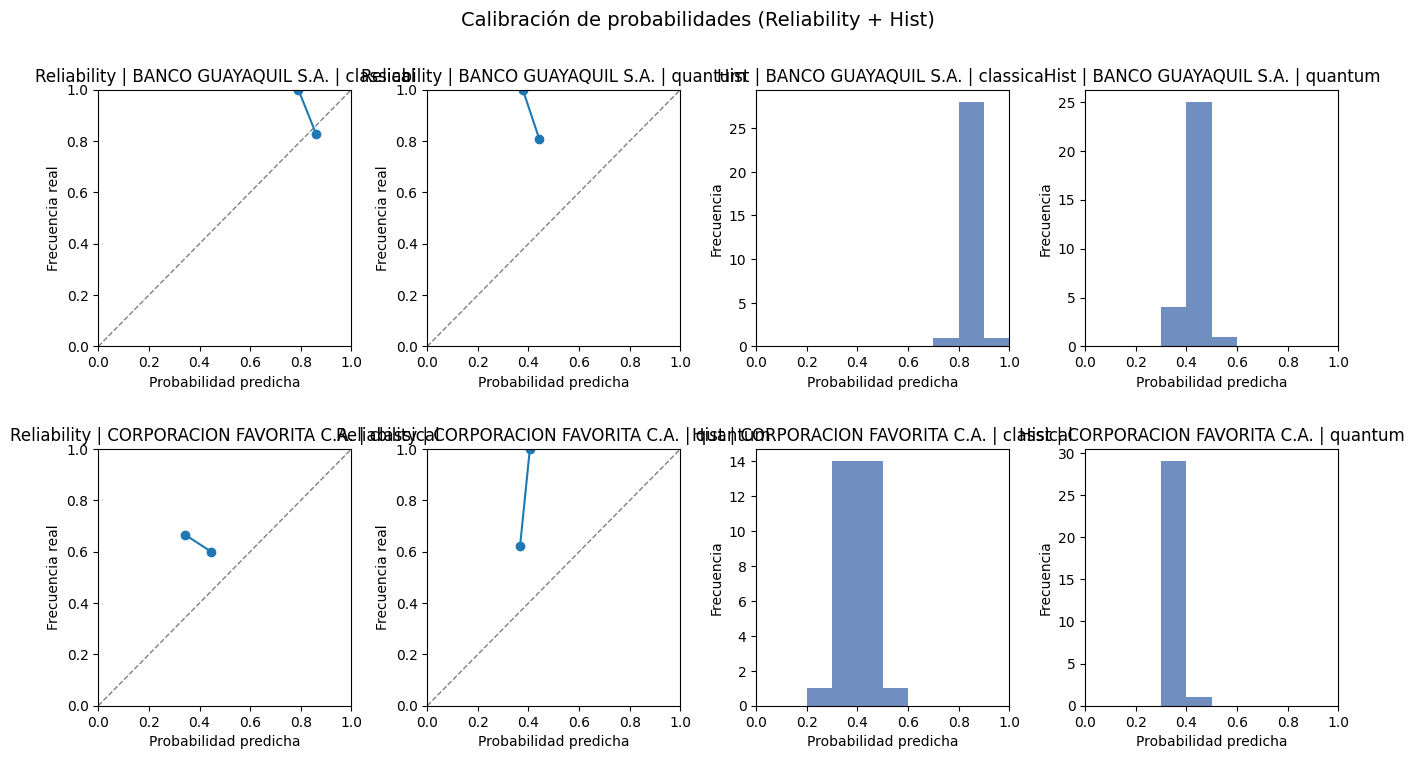

In [7]:
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(nrows=2, ncols=4, wspace=0.3, hspace=0.4)

for i, company in enumerate(COMPANIES):
    for j, model_family in enumerate(MODEL_FAMILIES):
        ax_rel = fig.add_subplot(gs[i, j])
        payload = results[(company, model_family)]
        ax_rel.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
        ax_rel.plot(payload['prob_pred'], payload['prob_true'], marker='o')
        ax_rel.set_title(f'Reliability | {company} | {model_family}')
        ax_rel.set_xlabel('Probabilidad predicha')
        ax_rel.set_ylabel('Frecuencia real')
        ax_rel.set_xlim(0, 1)
        ax_rel.set_ylim(0, 1)

        ax_hist = fig.add_subplot(gs[i, j + 2])
        ax_hist.hist(payload['proba'], bins=10, range=(0, 1), color='#4C72B0', alpha=0.8)
        ax_hist.set_title(f'Hist | {company} | {model_family}')
        ax_hist.set_xlabel('Probabilidad predicha')
        ax_hist.set_ylabel('Frecuencia')
        ax_hist.set_xlim(0, 1)

fig.suptitle('Calibración de probabilidades (Reliability + Hist)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUT_PNG, dpi=150)
OUT_PNG

In [8]:
if not OUT_CSV.exists():
    raise FileNotFoundError(f'CSV no encontrado: {OUT_CSV}')
if not OUT_PNG.exists():
    raise FileNotFoundError(f'PNG no encontrado: {OUT_PNG}')

print('Archivos generados correctamente:')
print(f'- {OUT_CSV.as_posix()}')
print(f'- {OUT_PNG.as_posix()}')
display(metrics_df)

Archivos generados correctamente:
- ../results/fase4_comparativa/BVG_subfase8b_calibracion.csv
- ../results/fase4_comparativa/BVG_calibracion_plot.png


,company,model_family,ece,mean_proba,std_proba,pct_proba_above_60,pct_proba_below_40
0,BANCO GUAYAQUIL S.A.,classical,0.039081,0.858456,0.026948,100.0,0.000000
1,BANCO GUAYAQUIL S.A.,quantum,0.399190,0.434143,0.032684,0.0,13.333333
2,CORPORACION FAVORITA C.A.,classical,0.239161,0.394172,0.057934,0.0,50.000000
3,CORPORACION FAVORITA C.A.,quantum,0.265538,0.367795,0.015530,0.0,96.666667
